# RQ1 — Ideology and Emotional Tone
## *Words in Power, Words in Opposition* — ENSAE NLP Project 2026
### Author: Salma El-Aazdoudi

---

## Research Question

> **Do candidates further from the political centre use a different emotional register in their *professions de foi*?**

### Hypothesis
Candidates at the ideological extremes (far-left, far-right) use **more emotionally intense** language than mainstream candidates. This would produce a **U-shaped** pattern: emotional intensity increases as we move away from the centre in either direction.

---
**Step 2 — Test whether ideology predicts emotion**  
I use OLS regression to test whether distance from the political centre (`dist_center`) predicts emotional intensity. 

## 0. Setup

In [3]:
# ── Libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {
    "far_left":  "#7c3aed",
    "left":      "#185FA5",
    "ecologist": "#16a34a",
    "right":     "#A32D2D",
    "far_right": "#7f1d1d",
}
POSITION_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
POSITION_LABELS = ["Far left", "Left", "Ecologist", "Right", "Far right"]

print("All libraries loaded.")


All libraries loaded.


In [4]:
# ── Load df_full ─────────────────────────────────────────────────────────
df = pd.read_csv("df_full_merged.csv")

## 1. Emotional Tone by Political Bloc: Descriptive Patterns

### 1.1. Emotional Intensity

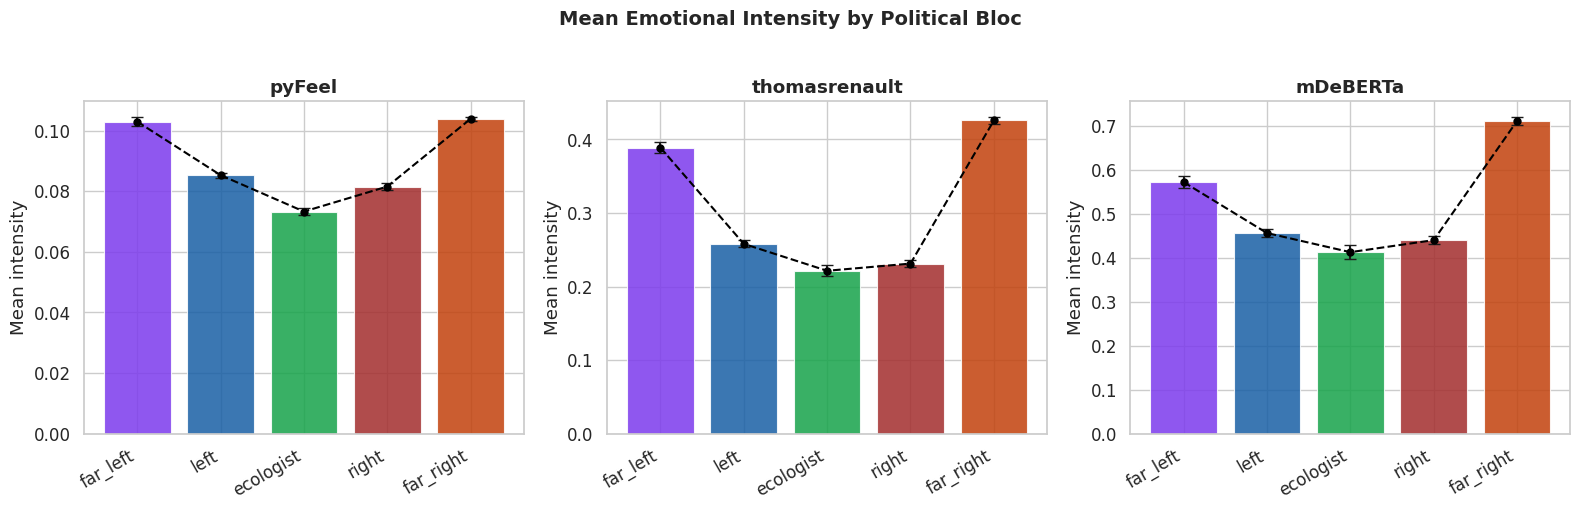

Figures saved.


In [6]:
INTENSITY_COLS = {
    "pyFeel":        "feel_intensity_nrc",
    "thomasrenault": "tr_intensity_nrc",
    "mDeBERTa":      "zs_intensity_nrc",
}
BLOC_ORDER = ["far_left", "left", "ecologist", "right", "far_right"]
COLORS     = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]

sns.set_theme(style="whitegrid", font_scale=1.1)

# ── 1. Barplot intensité par bloc — 3 modèles côte à côte ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Mean Emotional Intensity by Political Bloc",
             fontsize=14, fontweight="bold", y=1.02)

for ax, (label, col) in zip(axes, INTENSITY_COLS.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    stats = (
        df.groupby("bloc")[col]
        .agg(["mean", "std", "count"])
        .reindex(BLOC_ORDER)
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    ax.bar(BLOC_ORDER, stats["mean"], color=COLORS, alpha=0.85,
           yerr=stats["ci95"], capsize=4, edgecolor="white", linewidth=0.8)
    ax.plot(range(len(BLOC_ORDER)), stats["mean"].values,
            color="black", linewidth=1.5, linestyle="--",
            marker="o", markersize=5)
    ax.set_title(label, fontweight="bold")
    ax.set_xticklabels(BLOC_ORDER, rotation=30, ha="right")
    ax.set_ylabel("Mean intensity")

plt.tight_layout()
plt.savefig("RQ1_barplot_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figures saved.")

A U-shaped pattern is visible across all three panels: far-left and 
far-right candidates score higher than mainstream candidates, with ecologists and 
the mainstream right consistently at the bottom.

The pattern is clearest in thomasrenault, where the gap between the extremes and 
the centre is largest (far-right: 0.43, ecologist: 0.23). pyFeel shows the same 
shape but with narrower differences. mDeBERTa confirms the 
U-shape directionally but with higher absolute scores overall, consistent with the 
saturation problem documented in the emotion_measurement notebook.

One asymmetry is worth noting: across all three models, far-right candidates score 
slightly higher than far-left candidates. This suggests that the emotional intensity 
of the far-right is not simply a mirror image of the far-left (the two extremes 
may differ in *kind* as well as *degree*), a question explored in the 
per-emotion analysis below.

### 1.2 — Per-Emotion Patterns by Political Bloc

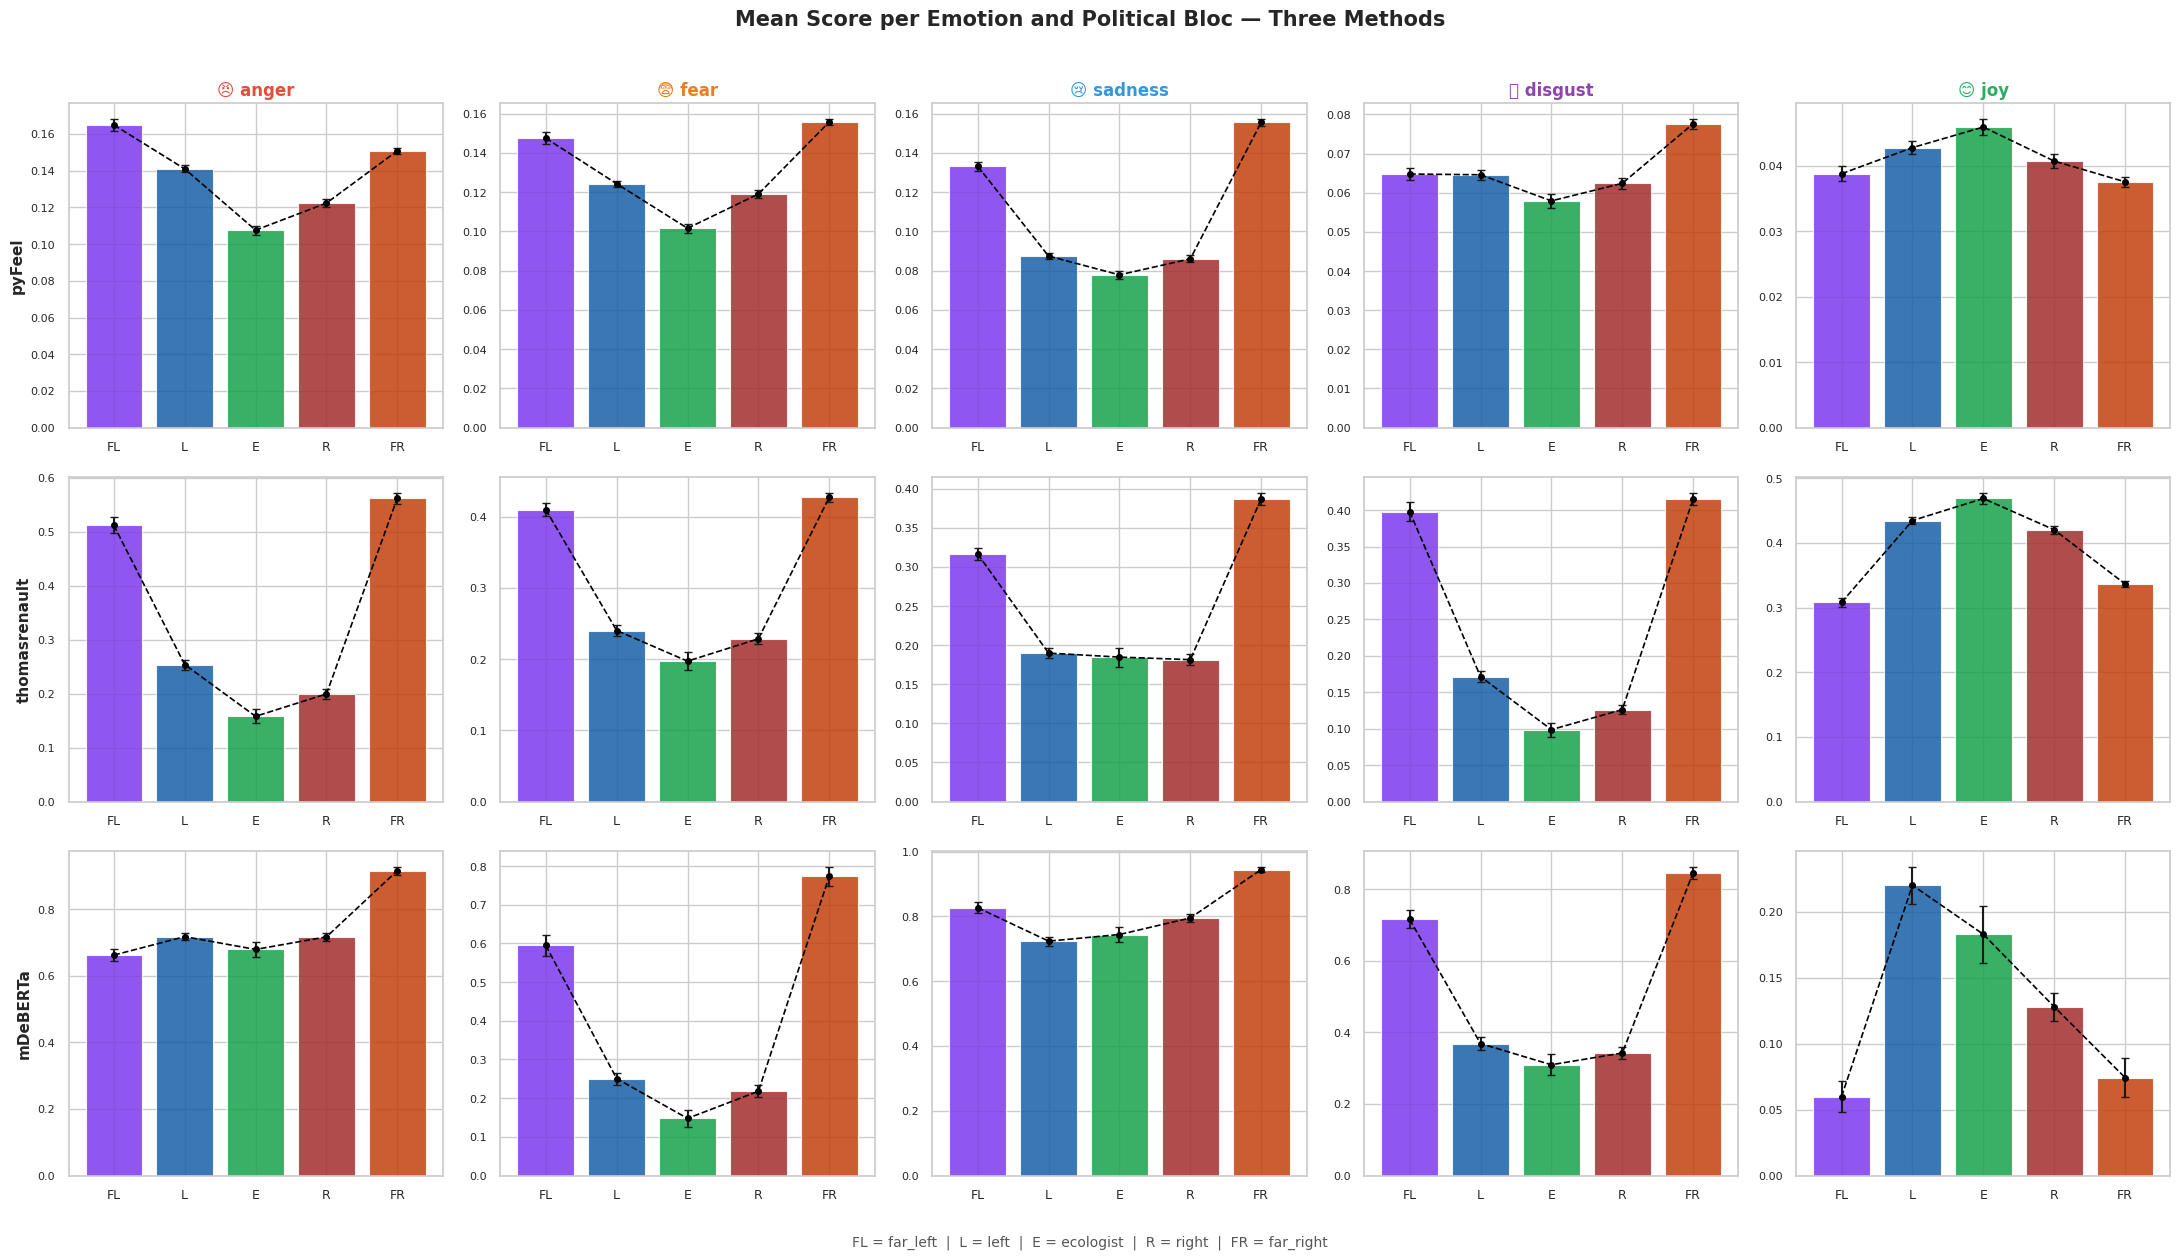

Figure saved: RQ1_per_emotion_threemethods.png


In [ ]:
# ── Per-emotion barplots — 3 modèles, 5 émotions partagées ───────────────

EMOTIONS_PER_MODEL = {
    "pyFeel": {
        "anger":   "feel_angry",
        "fear":    "feel_fear",
        "sadness": "feel_sadness",
        "disgust": "feel_disgust",
        "joy":     "feel_joy",
    },
    "thomasrenault": {
        "anger":   "tr_anger",
        "fear":    "tr_fear",
        "sadness": "tr_sadness",
        "disgust": "tr_disgust",
        "joy":     "tr_joy",
    },
    "mDeBERTa": {
        "anger":   "zs_anger",
        "fear":    "zs_fear",
        "sadness": "zs_sadness",
        "disgust": "zs_disgust",
        "joy":     "zs_joy",
    },
}

EMOTION_COLORS = {
    "anger":   "#e74c3c",
    "fear":    "#e67e22",
    "sadness": "#3498db",
    "disgust": "#8e44ad",
    "joy":     "#27ae60",
}

EMOTIONS   = ["anger", "fear", "sadness", "disgust", "joy"]
BLOC_ORDER = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]

# ── Layout : 3 modèles × 5 émotions ──────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 12), sharey=False)
fig.suptitle("Mean Score per Emotion and Political Bloc — Three Methods",
             fontsize=15, fontweight="bold", y=1.01)

for row_idx, (model_name, emotion_cols) in enumerate(EMOTIONS_PER_MODEL.items()):
    for col_idx, emotion in enumerate(EMOTIONS):
        ax  = axes[row_idx, col_idx]
        col = emotion_cols[emotion]

        if col not in df.columns:
            ax.set_visible(False)
            continue

        stats = (
            df.groupby("bloc")[col]
            .agg(["mean", "std", "count"])
            .reindex(BLOC_ORDER)
        )
        stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

        ax.bar(BLOC_ORDER, stats["mean"],
               color=BLOC_COLORS, alpha=0.85,
               yerr=stats["ci95"], capsize=3,
               edgecolor="white", linewidth=0.8)
        ax.plot(range(len(BLOC_ORDER)), stats["mean"].values,
                color="black", linewidth=1.2, linestyle="--",
                marker="o", markersize=4)

        # Titre colonne (émotion) uniquement sur la première ligne
        if row_idx == 0:
            emoji = {"anger": "😠", "fear": "😨", "sadness": "😢",
                     "disgust": "🤢", "joy": "😊"}[emotion]
            ax.set_title(f"{emoji} {emotion}", fontweight="bold",
                         color=EMOTION_COLORS[emotion], fontsize=12)

        # Label modèle uniquement sur la première colonne
        if col_idx == 0:
            ax.set_ylabel(model_name, fontweight="bold", fontsize=11)

        ax.set_xticks(range(len(BLOC_ORDER)))
        ax.set_xticklabels(
            ["FL", "L", "E", "R", "FR"],  # abréviations pour lisibilité
            fontsize=9
        )
        ax.tick_params(axis="y", labelsize=8)

# Légende abréviations
fig.text(0.5, -0.02,
         "FL = far_left  |  L = left  |  E = ecologist  |  R = right  |  FR = far_right",
         ha="center", fontsize=10, color="#555")

plt.tight_layout()
plt.savefig("RQ1_per_emotion_threemethods.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: RQ1_per_emotion_threemethods.png")

The results below are based primarily on **thomasrenault**, the most reliable model 
for this corpus (see emotion_measurement notebook). pyFeel and mDeBERTa are reported as 
robustness checks.

**Anger** shows the clearest U-shape. Far-left (0.52) and far-right (0.57) score 
markedly higher than the mainstream left (0.26), ecologists (0.14) and mainstream 
right (0.20). Both pyFeel and mDeBERTa confirm this pattern.

**Fear** follows a similar shape but with a right-side asymmetry: far-right 
candidates score higher than far-left on fear across all three models. Far-right 
rhetoric in this corpus relies more on threat framing than far-left rhetoric, 
which mobilises through indignation (see emotion_measurement notebook).

**Disgust** shows a similar asymmetry. Far-left scores high (~0.40) but far-right 
scores higher (~0.40), and the gap is larger on mDeBERTa. This is consistent with 
the moral condemnation register of far-right electoral rhetoric in the 1990s.

**Joy** inverts the pattern. Ecologists and left candidates score highest : 
consistent with the forward-looking register of Green and mainstream 
left manifestos. Far-right candidates score lowest on joy across all three models, 
confirming that emotional intensity at the extremes is driven by negative affect, 
not enthusiasm.

## 3 — Testing the U-Shape: OLS with Bloc Dummies

In [5]:
import statsmodels.formula.api as smf

INTENSITY_COLS = {
    "pyFeel":        "feel_intensity_nrc",
    "thomasrenault": "tr_intensity_nrc",
    "mDeBERTa":      "zs_intensity_nrc",
}

# Référence = "left" (centre-gauche, le plus proche du centre)
df["bloc"] = pd.Categorical(df["bloc"],
    categories=["left", "ecologist", "right", "far_left", "far_right"])

print("=" * 65)
print("OLS — bloc dummies (ref = left)")
print("=" * 65)

for label, col in INTENSITY_COLS.items():
    if col not in df.columns:
        continue
    model = smf.ols(
        f"{col} ~ C(bloc, Treatment('left')) + C(year_dummy)",
        data=df.dropna(subset=[col, "bloc", "year_dummy"])
    ).fit()
    print(f"\n── {label} ──")
    print(f"  R² = {model.rsquared:.4f}  |  N = {int(model.nobs):,}")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "bloc" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:45} β={coef:+.4f}  p={pval:.4f}  {stars}")

OLS — bloc dummies (ref = left)

── pyFeel ──
  R² = 0.1880  |  N = 6,446
  C(bloc, Treatment('left'))[T.ecologist]       β=-0.0112  p=0.0000  ***
  C(bloc, Treatment('left'))[T.right]           β=-0.0034  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_left]        β=+0.0178  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_right]       β=+0.0194  p=0.0000  ***

── thomasrenault ──
  R² = 0.3623  |  N = 6,446
  C(bloc, Treatment('left'))[T.ecologist]       β=-0.0672  p=0.0000  ***
  C(bloc, Treatment('left'))[T.right]           β=-0.0416  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_left]        β=+0.1242  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_right]       β=+0.1374  p=0.0000  ***



── mDeBERTa ──
  R² = 0.2158  |  N = 6,446
  C(bloc, Treatment('left'))[T.ecologist]       β=-0.0963  p=0.0000  ***
  C(bloc, Treatment('left'))[T.right]           β=-0.0416  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_left]        β=+0.1043  p=0.0000  ***
  C(bloc, Treatment('left'))[T.far_right]       β=+0.2025  p=0.0000  ***


OLS regressions with bloc dummies confirm the U-shape across 
all three models. On thomasrenault, far-left and far-right score significantly 
higher than the mainstream left (β = +0.124 and β = +0.137, p < 0.001), while 
ecologists (β = −0.067) and the mainstream right (β = −0.042) score lower. 
The model explains 36% of the variance (the highest R² across the three methods).

pyFeel and mDeBERTa confirm the same pattern. Far-right candidates score slightly 
higher than far-left across most models, but the two extremes are comparable 
in intensity.

## 4- Sensitivity Analysis

In [14]:
import statsmodels.formula.api as smf
import pandas as pd

INTENSITY_COLS = {
    "pyFeel":        "feel_intensity_nrc",
    "thomasrenault": "tr_intensity_nrc",
    "mDeBERTa":      "zs_intensity_nrc",
}

years = [1981, 1993]

print("=" * 65)
print("SENSITIVITY — OLS by year (ref = left)")
print("=" * 65)

for year in years:
    df_year = df[df["year"] == year].copy()
    n_year  = len(df_year)
    print(f"\n{'─'*65}")
    print(f"YEAR {year} — N = {n_year:,}")
    print(f"{'─'*65}")
    print(f"Blocs: {df_year['bloc'].value_counts().to_dict()}")

    for label, col in INTENSITY_COLS.items():
        if col not in df_year.columns:
            continue
        df_model = df_year.dropna(subset=[col, "bloc"])
        # Vérifier qu'on a assez de blocs
        blocs_available = df_model["bloc"].unique()
        if len(blocs_available) < 3:
            print(f"\n  {label}: not enough blocs ({blocs_available}), skipping.")
            continue
        try:
            model = smf.ols(
                f"{col} ~ C(bloc, Treatment('left'))",
                data=df_model
            ).fit()
            print(f"\n  ── {label} — R²={model.rsquared:.4f} | N={int(model.nobs):,} ──")
            for name, coef, pval in zip(
                model.params.index, model.params.values, model.pvalues.values
            ):
                if "bloc" in name:
                    stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
                    print(f"    {name:45} β={coef:+.4f}  p={pval:.4f}  {stars}")
        except Exception as e:
            print(f"  {label}: error — {e}")

SENSITIVITY — OLS by year (ref = left)

─────────────────────────────────────────────────────────────────
YEAR 1981 — N = 2,388
─────────────────────────────────────────────────────────────────
Blocs: {'left': 1298, 'right': 615, 'far_left': 376, 'far_right': 58, 'ecologist': 41}

  ── pyFeel — R²=0.0399 | N=2,388 ──
    C(bloc, Treatment('left'))[T.ecologist]       β=+0.0011  p=0.7456  n.s.
    C(bloc, Treatment('left'))[T.right]           β=+0.0038  p=0.0004  ***
    C(bloc, Treatment('left'))[T.far_left]        β=+0.0120  p=0.0000  ***
    C(bloc, Treatment('left'))[T.far_right]       β=+0.0126  p=0.0000  ***

  ── thomasrenault — R²=0.2088 | N=2,388 ──
    C(bloc, Treatment('left'))[T.ecologist]       β=+0.1051  p=0.0000  ***
    C(bloc, Treatment('left'))[T.right]           β=+0.0473  p=0.0000  ***
    C(bloc, Treatment('left'))[T.far_left]        β=+0.1095  p=0.0000  ***
    C(bloc, Treatment('left'))[T.far_right]       β=+0.1999  p=0.0000  ***

  ── mDeBERTa — R²=0.0972 | N=2,38

Rerunning the regressions separately for 1981 and 1993 confirms that the U-shape 
is not a temporal artefact. In both years, far-left and far-right score 
significantly higher than the mainstream left on all three models (p < 0.001).

Two differences between years are worth noting. In 1981, the pattern is less 
symmetric — the mainstream right also scores above the left on thomasrenault 
(β = +0.047), suggesting a more uniformly emotional electoral context following 
Mitterrand's election. In 1993, the U-shape is cleaner: ecologists and the 
mainstream right both score below the left, and the extremes stand out more clearly.

The R² increases substantially from 1981 to 1993 on thomasrenault (0.21 → 0.46), 
suggesting that ideological position became a stronger predictor of emotional 
register over time.

## 5- Conclusion 
Do candidates further from the political centre use a different emotional register in their professions de foi?
The answer is yes. Candidates further from the political centre use a 
more intense emotional register in their *professions de foi*, and this pattern 
holds across three measurement methods, both electoral years, and all 
five emotion dimensions.

The U-shape is most clearly captured by thomasrenault, where far-left and far-right 
candidates score 12–14 points higher than the mainstream left on composite intensity, 
while ecologists and the mainstream right score below it. The result is statistically 
significant at p < 0.001 and explains 36% of the variance in emotional intensity 
(a high R² for a purely text-based measure).

The two extremes are not mirror images of each other. Far-left intensity is driven 
primarily by anger and disgust. Far-right intensity draws more heavily on fear and sadness alongside 
anger. Joy is the one emotion that follows an inverted pattern: 
ecologists and the mainstream left score highest, confirming that positive affect 
is a feature of the centre, not the extremes.

The sensitivity analysis shows the pattern is not a temporal artefact: the U-shape 
holds in both 1981 and 1993, though it becomes sharper over time. The R² nearly 
doubles between the two years on thomasrenault, suggesting that ideological 
position became a stronger predictor of emotional register between the two elections.